In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Conv2D,MaxPool2D,Flatten,Dropout,BatchNormalization
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import cv2
import os

from tqdm import tqdm

In [2]:
# Dataseti indirin (URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia)
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

# Zip dosyasını açın
!unzip chest-xray-pneumonia.zip

Görüntülenen çıkış son 5000 satıra kısaltıldı.
  inflating: chest_xray/train/NORMAL/IM-0435-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0435-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001-0002.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0438-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001-0002.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0440-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0441-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0442-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0444-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0445-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0446-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0447-0001.jpeg  
  inflating: che

In [3]:
!ls  # chest_xray klasörünü göreceksiniz

chest_xray  chest-xray-pneumonia.zip  sample_data


In [4]:
!ls chest_xray  # train, test, val klasörlerini göreceksiniz
!ls chest_xray/train  # NORMAL ve PNEUMONIA alt klasörlerini göreceksiniz

chest_xray  __MACOSX  test  train  val
NORMAL	PNEUMONIA


In [6]:
labels = ["PNEUMONIA","NORMAL"]
img_size = 150 # 150x150

In [8]:
def get_training_data(data_dir):
  data = []
  for label in labels: # NORMAL
    path = os.path.join(data_dir,label)
    class_num = labels.index(label)
    for img in tqdm(os.listdir(path)):
      #print(img)
      try:
        # görüntüyü oku ve işle
        img_arr = cv2.imread(os.path.join(path,img),cv2.IMREAD_GRAYSCALE)
        if img_arr is None:
          continue
        # görüntüyü yeniden boyutlandır
        resized_arr = cv2.resize(img_arr,(img_size,img_size))
        # görüntüyü listeye ekle
        data.append([resized_arr,class_num])
      except Exception as e:
        print("Error:",e)
  return np.array(data,dtype=object)


In [9]:
train = get_training_data("chest_xray/train")
test = get_training_data("chest_xray/test")
val = get_training_data("chest_xray/val")

100%|██████████| 8/8 [00:00<00:00, 154.01it/s]


<Axes: ylabel='count'>

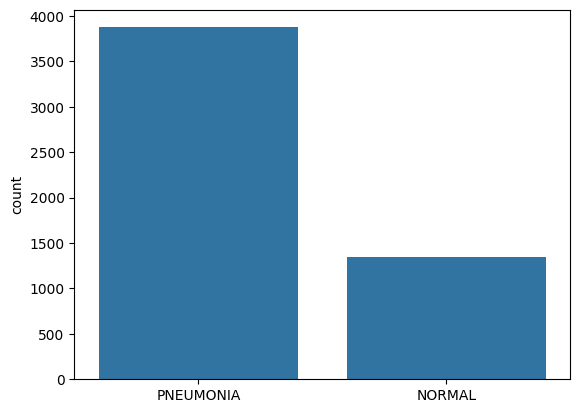

In [11]:
# data visualization and preprocessing
l = []
for i in train:
  if(i[1]==0):
    l.append("PNEUMONIA")
  else:
    l.append("NORMAL")

sns.countplot(x=l)

In [12]:
x_train = []
y_train = []

x_test = []
y_test = []

x_val = []
y_val = []

In [13]:
for feature,label in train:
  x_train.append(feature)
  y_train.append(label)

for feature,label in test:
  x_test.append(feature)
  y_test.append(label)

for feature,label in val:
  x_val.append(feature)
  y_val.append(label)

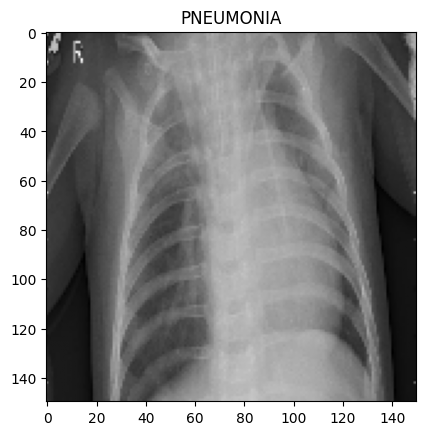

In [16]:
plt.figure()
plt.imshow(train[0][0],cmap = "gray")
plt.title(labels[train[0][1]])
plt.show()

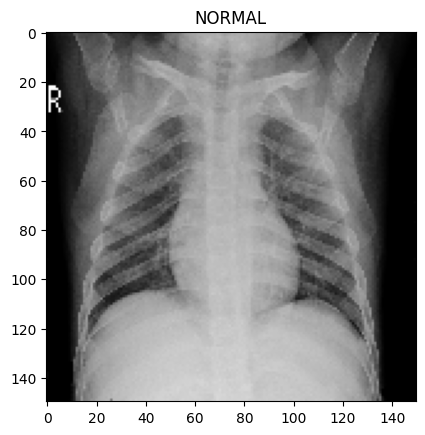

In [17]:
plt.figure()
plt.imshow(train[-1][0],cmap = "gray")
plt.title(labels[train[-1][1]])
plt.show()

In [18]:
# normalizasyon: [0,1]
# [0,255]/255 = [0,1]
x_train = np.array(x_train)/255
x_test = np.array(x_test)/255
x_val = np.array(x_val)/255

In [21]:
# (5216,150,150) -> (5216,150,150,1)
x_train = x_train.reshape(-1,img_size,img_size,1) # Use the reshape method of the array
x_test = x_test.reshape(-1,img_size,img_size,1)  # Use the reshape method of the array
x_val = x_val.reshape(-1,img_size,img_size,1)   # Use the reshape method of the array

In [22]:
# liste olarak kabul etmiyor
y_train = np.array(y_train)
y_test = np.array(y_test)
y_val = np.array(y_val)

In [24]:
datagen = ImageDataGenerator(
    featurewise_center=False, # veri setinin genel ortalamasını 0 yapar
    samplewise_center=False, # her bir örneğin ortalamasını 0 yapar
    featurewise_std_normalization=False, # veriyi verinin std bölme
    samplewise_std_normalization=False, # her bir örneği kendi std sapmasına bölme işlemi
    zca_whitening=False,  # zca beyazlatma yöntemi, korelasyonu azaltma
    rotation_range=30, # resimleri x derece rastgele kaydırma
    zoom_range=0.2, # rastgele yakınlaştırma işlemi
    width_shift_range=0.1, # yatay olarak rastgele kaydırma
    height_shift_range=0.1, # resimleri dikey olarka rastgele kaydırma
    horizontal_flip=True, # resimleri rastgele yatay olarka çevirir
    vertical_flip=True,  # resimleri rastgele dikey olarak çevirir
)

In [25]:
datagen.fit(x_train)

In [27]:
#create deep learnining model and train

"""
Feature Extraction Block:
(con2d - Normalizasyon - MaxPooling)
(con2d - dropout - Normalizasyon - MaxPooling)
(con2d - Normalizasyon - MaxPooling)
(con2d - dropout - Normalizasyon - MaxPooling)
(con2d - dropout - Normalizasyon - MaxPooling)
Classification Block:
flatten - Dense - Dropout - Dense (output)
Compiner: optimizer (rmsprop), loss (binary_crossentropy), metric (accuracy)
"""

'\nFeature Extraction Block:\n(con2d - Normalizasyon - MaxPooling)\n(con2d - dropout - Normalizasyon - MaxPooling)\n(con2d - Normalizasyon - MaxPooling)\n(con2d - dropout - Normalizasyon - MaxPooling)\n(con2d - dropout - Normalizasyon - MaxPooling)\nClassification Block:\nflatten - Dense - Dropout - Dense (output)\nCompiner: optimizer (rmsprop), loss (binary_crossentropy), metric (accuracy)\n'

In [33]:
model = Sequential()

model.add(Conv2D(128,(7,7),strides = 1,padding="same", activation="relu",input_shape=(150,150,1)))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2),strides=2,padding="same")) # Pass strides to MaxPool2D

model.add(Conv2D(64,(5,5),strides = 1,padding="same", activation="relu"))
model.add(Dropout(0.1))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2),strides=2,padding="same")) # Pass strides to MaxPool2D

model.add(Conv2D(32,(3,3),strides = 1,padding="same", activation="relu"))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2),strides=2,padding="same")) # Pass strides to MaxPool2D

model.add(Flatten())
model.add(Dense(units=128,activation="relu"))
model.add(Dropout(0.2))
model.add(Dense(units=1,activation="sigmoid"))

model.compile(optimizer="rmsprop",loss="binary_crossentropy",metrics=["accuracy"])
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)                   │ (None, 150, 150, 128)       │           6,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ (None, 150, 150, 128)       │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 75, 75, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 75, 75, 64)          │         204,864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 75, 75, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_11               │ (None, 75, 75, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_10 (MaxPooling2D)      │ (None, 38, 38, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_12 (Conv2D)                   │ (None, 38, 38, 32)          │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_12               │ (None, 38, 38, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_11 (MaxPooling2D)      │ (None, 19, 19, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 11552)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │       1,478,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,709,537 (6.52 MB)

 Trainable params: 1,709,089 (6.52 MB)

 Non-trainable params: 448 (1.75 KB)

In [35]:
learning_rate_reduction = ReduceLROnPlateau(
    monitor="val_accuracy",
    patience=2,verbose=1,
    factor=0.3,min_lr=0.000001)
epoch_number = 10
history = model.fit(datagen.flow(x_train,y_train,batch_size=32),
          epochs=epoch_number,
          validation_data=datagen.flow(x_test,y_test),
          callbacks=[learning_rate_reduction])

print("Loss of Model:",model.evaluate(x_test,y_test)[0])
print("Accuracy of Model:",model.evaluate(x_test,y_test)[1]*100)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 15s 89ms/step - accuracy: 0.9232 - loss: 0.2039 - val_accuracy: 0.8077 - val_loss: 0.4837 - learning_rate: 3.0000e-04
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 15s 90ms/step - accuracy: 0.9283 - loss: 0.2009 - val_accuracy: 0.5192 - val_loss: 0.9854 - learning_rate: 3.0000e-04
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.9268 - loss: 0.1848
Epoch 3: ReduceLROnPlateau reducing learning rate to 9.000000427477062e-05.
163/163 ━━━━━━━━━━━━━━━━━━━━ 16s 100ms/step - accuracy: 0.9268 - loss: 0.1848 - val_accuracy: 0.4135 - val_loss: 3.5170 - learning_rate: 3.0000e-04
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 17s 103ms/step - accuracy: 0.9319 - loss: 0.1742 - val_accuracy: 0.4551 - val_loss: 1.4635 - learning_rate: 9.0000e-05
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.9335 - loss: 0.1711
Epoch 5: ReduceLROnPlateau reducing learning rate to 2.700000040931627e-05.
163/163 ━━━━━━━━━━━━━━━━━━━━ 16s 99ms/step - accura

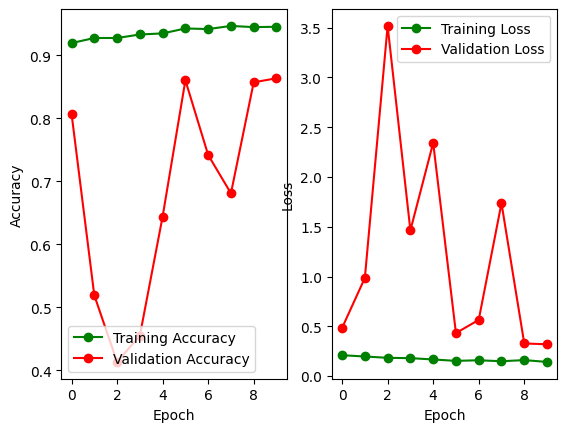

In [37]:
# evalution
epochs = [i for i in range(epoch_number)]
fig,ax = plt.subplots(1,2)

train_acc = history.history["accuracy"]
train_loss = history.history["loss"]
val_acc = history.history["val_accuracy"]
val_loss = history.history["val_loss"]

ax[0].plot(epochs,train_acc,"go-",label="Training Accuracy")
ax[0].plot(epochs,val_acc,"ro-",label="Validation Accuracy")
ax[0].legend() # Changed lagend() to legend()
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Accuracy")

ax[1].plot(epochs,train_loss,"go-",label="Training Loss")
ax[1].plot(epochs,val_loss,"ro-",label="Validation Loss")
ax[1].legend() # Changed lagend() to legend()
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Loss")

plt.show()